In [1]:
# Installing packages and Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA

    

data = pd.read_csv('../data/kyle_schwarber_full_data.csv')
data['hits'] = data['events'].isin(['single', 'double', 'triple', 'home_run'])
data['zone'] = data['zone'].astype('category')
data['pitch_number'] = data['pitch_number'].astype('category')
data['pitch_count'] = data['balls'].astype(str) + '-' + data['strikes'].astype(str)

features = ['zone', 'p_throws', 'pitch_count', 'effective_speed', 'release_spin_rate', 'pitch_number', 'pitch_name', 'hits']
data = data[features]
data = data.dropna()

In [24]:
# Plot Code:
from matplotlib.lines import Line2D
target_map = {
    "0": 'Not Hit',
    "1": 'Hit'
}
colors = ["#1f77b4", "#ff7f0e"]

def plot_embedding(embedding, labels, title, x_label="Component 1", y_label="Component 2"):
    label_ids = np.asarray(labels, dtype=int)
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=[colors[i] for i in label_ids],
        s=6,
        alpha=0.5,
    )
    legend_handles = [
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label=target_map[str(i)],
            markerfacecolor=colors[i],
            markersize=6
        )
        for i in range(len(colors))
    ]

    plt.legend(
        handles=legend_handles,
        title="Class",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.tight_layout()

In [3]:
X = pd.DataFrame(data.drop(columns=['hits']))
y = pd.Series(data['hits'], name='target')

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 307, stratify = y)


from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', PCA(n_components = 2, random_state = 307))
])

X_pca_2d = model.fit_transform(X_train)

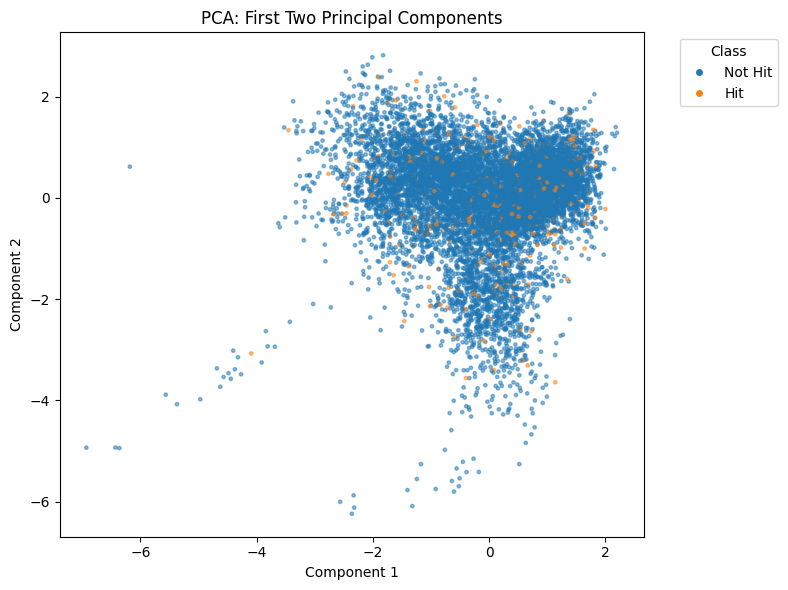

In [25]:
plot_embedding(X_pca_2d, y_train,  title="PCA: First Two Principal Components")